<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [20]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [21]:
# Posibles bandas
os.listdir("./songs_dataset/")

['beatles.txt',
 'notorious_big.txt',
 'al-green.txt',
 'nirvana.txt',
 'paul-simon.txt',
 'missy-elliott.txt',
 'adele.txt',
 'disney.txt',
 'rihanna.txt',
 'dickinson.txt',
 'bob-marley.txt',
 'drake.txt',
 'jimi-hendrix.txt',
 'lil-wayne.txt',
 'amy-winehouse.txt',
 'lady-gaga.txt',
 'bjork.txt',
 'kanye-west.txt',
 'nicki-minaj.txt',
 'bieber.txt',
 'nursery_rhymes.txt',
 'bob-dylan.txt',
 'radiohead.txt',
 'nickelback.txt',
 'michael-jackson.txt',
 'dr-seuss.txt',
 'prince.txt',
 'leonard-cohen.txt',
 'cake.txt',
 'britney-spears.txt',
 'janisjoplin.txt',
 'blink-182.txt',
 'bruce-springsteen.txt',
 'eminem.txt',
 'ludacris.txt',
 'notorious-big.txt',
 'patti-smith.txt',
 'lorde.txt',
 'dolly-parton.txt',
 'alicia-keys.txt',
 'r-kelly.txt',
 'joni-mitchell.txt',
 'lin-manuel-miranda.txt',
 'bruno-mars.txt',
 'Kanye_West.txt',
 'dj-khaled.txt',
 'johnny-cash.txt',
 'kanye.txt',
 'Lil_Wayne.txt']

In [22]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_53063/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [23]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [24]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [25]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [26]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [27]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [28]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [30]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [31]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [32]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [33]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [34]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [35]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [36]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [37]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [38]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [39]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [40]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [41]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [43]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
# fig.show(renderer="colab") # esto para plotly en colab


# Para visualizaciòn local.
import plotly.io as pio
print(pio.renderers)
pio.renderers.default = "browser"
fig.show()

Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



Gtk-Message: 17:48:12.233: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.


In [44]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
# fig.show(renderer="colab") # esto para plotly en colab
pio.renderers.default = "browser"
fig.show()

Gtk-Message: 17:48:20.053: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.


In [45]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

### Datos

Para este desafío se utilizará como corpus el texto completo de **La Metamorfosis** de Franz Kafka (archivo `laMetamorfosis.txt`).
Se trata de un corpus con características distintas al anterior: mientras que el dataset de canciones estaba compuesto por miles de versos cortos (una línea por documento) provenientes de muchas canciones distintas, en este caso es un solo texto y es más chico.

In [46]:
# Cargar el corpus de La Metamorfosis
with open('laMetamorfosis.txt', 'r', encoding='utf-8') as f:
    texto = f.read()

print("Cantidad de caracteres del corpus:", len(texto))
print(texto[:400])

Cantidad de caracteres del corpus: 121076
I

Cuando Gregorio Samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto. Estaba tumbado sobre su espalda dura, y en forma de caparazón y, al levantar un poco la cabeza veía un vientre abombado, parduzco, dividido por partes duras en forma de arco, sobre cuya protuberancia apenas podía mantenerse el cobertor, a punto ya de resba


### 1 - Preprocesamiento

A diferencia del dataset de canciones, que ya venía organizado con un verso por linea el archivo de La Metamorfosis es un texto corrido, separado en parrafos por lineas en blanco. Por eso, antes de tokenizar, se realizo lo siguiente:

- Se unificaron los saltos de linea dentro de cada párrafo, para no cortar oraciones por la mitad.
- Se dividio el texto en oraciones utilizando el tokenizador de oraciones de NLTK (modelo para español), ya que en este corpus la oración es la unidad de contexto natural para entrenar los embeddings (equivalente al verso del dataset de canciones).
- Finalmente, cada oración se transformo en una secuencia de palabras con `text_to_word_sequence`, tal como se hizo en el ejemplo de la cátedra.

In [50]:
import re
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# Se unifican los saltos de línea dentro de cada párrafo para no partir oraciones a la mitad
texto_unificado = re.sub(r'\n+', ' ', texto)

# Se separa el texto en oraciones
oraciones = sent_tokenize(texto_unificado, language='spanish')

print("Cantidad de oraciones encontradas:", len(oraciones))
oraciones[:3]

Cantidad de oraciones encontradas: 735


[nltk_data] Downloading package punkt to /home/lvillal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/lvillal/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['I Cuando Gregorio Samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto.',
 'Estaba tumbado sobre su espalda dura, y en forma de caparazón y, al levantar un poco la cabeza veía un vientre abombado, parduzco, dividido por partes duras en forma de arco, sobre cuya protuberancia apenas podía mantenerse el cobertor, a punto ya de resbalar al suelo.',
 'Sus muchas patas, ridículamente pequeñas en comparación con el resto de su tamaño, le vibraban desamparadas ante los ojos.']

In [51]:
# Se transforma cada oración en una secuencia de palabras
sentence_tokens_metamorfosis = [text_to_word_sequence(oracion) for oracion in oraciones]

# Se descartan oraciones de una sola palabra (por ejemplo, restos de números de capítulo como "I" o "II"),
# ya que no aportan contexto para el entrenamiento
sentence_tokens_metamorfosis = [tokens for tokens in sentence_tokens_metamorfosis if len(tokens) > 1]

print("Cantidad de oraciones tokenizadas:", len(sentence_tokens_metamorfosis))
sentence_tokens_metamorfosis[:3]

Cantidad de oraciones tokenizadas: 726


[['i',
  'cuando',
  'gregorio',
  'samsa',
  'se',
  'despertó',
  'una',
  'mañana',
  'después',
  'de',
  'un',
  'sueño',
  'intranquilo',
  'se',
  'encontró',
  'sobre',
  'su',
  'cama',
  'convertido',
  'en',
  'un',
  'monstruoso',
  'insecto'],
 ['estaba',
  'tumbado',
  'sobre',
  'su',
  'espalda',
  'dura',
  'y',
  'en',
  'forma',
  'de',
  'caparazón',
  'y',
  'al',
  'levantar',
  'un',
  'poco',
  'la',
  'cabeza',
  'veía',
  'un',
  'vientre',
  'abombado',
  'parduzco',
  'dividido',
  'por',
  'partes',
  'duras',
  'en',
  'forma',
  'de',
  'arco',
  'sobre',
  'cuya',
  'protuberancia',
  'apenas',
  'podía',
  'mantenerse',
  'el',
  'cobertor',
  'a',
  'punto',
  'ya',
  'de',
  'resbalar',
  'al',
  'suelo'],
 ['sus',
  'muchas',
  'patas',
  'ridículamente',
  'pequeñas',
  'en',
  'comparación',
  'con',
  'el',
  'resto',
  'de',
  'su',
  'tamaño',
  'le',
  'vibraban',
  'desamparadas',
  'ante',
  'los',
  'ojos']]

### 2 - Crear los vectores (word2vec)

Se creó el modelo generador de vectores utilizando la misma arquitectura Skipgram vista en clase. Sin embargo, dado que el corpus de La Metamorfosis es considerablemente más chico que el de canciones (una única novela corta, del orden de 20 mil palabras totales, frente a las 1846 líneas del dataset de la banda), se ajustaron algunos hiperparámetros:

- Se bajó `min_count` a 3, para no perder demasiado vocabulario relevante en un corpus chico.
- Se redujo `vector_size` a 100, ya que con menos datos de entrenamiento no tiene sentido buscar vectores de gran dimensionalidad (se perdería más en ruido que lo que se ganaría en expresividad).
- Se amplió `window` a 5, para compensar con más contexto por palabra la menor cantidad de oraciones disponibles.

In [52]:
# Se crea el modelo generador de vectores (Skipgram) para el corpus de La Metamorfosis
w2v_model_metamorfosis = Word2Vec(min_count=3,   # frecuencia mínima de palabra para incluirla en el vocabulario
                                   window=5,      # cant de palabras antes y desp de la predicha
                                   vector_size=100,  # dimensionalidad de los vectores
                                   negative=10,   # cantidad de negative samples... 0 es no se usa
                                   workers=1,     # si tienen más cores pueden cambiar este valor
                                   sg=1)          # modelo 0:CBOW  1:skipgram

# Se construye el vocabulario a partir de las oraciones tokenizadas
w2v_model_metamorfosis.build_vocab(sentence_tokens_metamorfosis)

print("Cantidad de oraciones en el corpus:", w2v_model_metamorfosis.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model_metamorfosis.wv.index_to_key))

Cantidad de oraciones en el corpus: 726
Cantidad de words distintas en el corpus: 948


### 3 - Entrenar embeddings

Se entrenó el modelo reutilizando el mismo callback definido en el ejemplo de la cátedra, para poder observar la evolución del loss época a época. Se incrementó la cantidad de épocas a 100 (contra las 20 utilizadas para el dataset de canciones), ya que al contar con un corpus más chico el modelo necesita recorrer varias veces las mismas oraciones para poder ajustar bien los vectores.

In [53]:
# Se entrena el modelo generador de vectores sobre el corpus de La Metamorfosis
w2v_model_metamorfosis.train(sentence_tokens_metamorfosis,
                              total_examples=w2v_model_metamorfosis.corpus_count,
                              epochs=100,
                              compute_loss=True,
                              callbacks=[callback()])

Loss after epoch 0: 268420.15625
Loss after epoch 1: 188444.59375
Loss after epoch 2: 183077.75
Loss after epoch 3: 179495.375
Loss after epoch 4: 181821.8125
Loss after epoch 5: 184041.1875
Loss after epoch 6: 185886.625
Loss after epoch 7: 186983.75
Loss after epoch 8: 184804.25
Loss after epoch 9: 183644.125
Loss after epoch 10: 177946.875
Loss after epoch 11: 153105.5
Loss after epoch 12: 151703.75
Loss after epoch 13: 150445.0
Loss after epoch 14: 149125.0
Loss after epoch 15: 148278.0
Loss after epoch 16: 147410.25
Loss after epoch 17: 145701.75
Loss after epoch 18: 143625.0
Loss after epoch 19: 143197.25
Loss after epoch 20: 140518.75
Loss after epoch 21: 140815.0
Loss after epoch 22: 140322.0
Loss after epoch 23: 137270.5
Loss after epoch 24: 137117.0
Loss after epoch 25: 126703.25
Loss after epoch 26: 120246.0
Loss after epoch 27: 121173.5
Loss after epoch 28: 119188.0
Loss after epoch 29: 118705.0
Loss after epoch 30: 119435.5
Loss after epoch 31: 118893.0
Loss after epoch 32

(1080351, 2081900)

### 4 - Ensayar

Se eligieron como términos de interés algunas palabras vinculadas a los ejes centrales de la obra: el protagonista (`gregorio`), su familia (`padre`, `hermana`) y uno de los objetos/espacios más presentes en la novela (`puerta`, elemento clave ya que buena parte de la acción transcurre con Gregorio encerrado en su habitación). Para cada término se buscaron las palabras más similares y las menos similares según los embeddings entrenados.

In [54]:
# Palabras que MÁS se relacionan con "gregorio"
w2v_model_metamorfosis.wv.most_similar(positive=["gregorio"], topn=10)

[('que', 0.5658999085426331),
 ('y', 0.5418949723243713),
 ('de', 0.5049145817756653),
 ('la', 0.47440534830093384),
 ('no', 0.47105640172958374),
 ('en', 0.44962063431739807),
 ('a', 0.44202786684036255),
 ('el', 0.41912704706192017),
 ('se', 0.4159535765647888),
 ('¿y', 0.37094026803970337)]

In [55]:
# Palabras que MENOS se relacionan con "gregorio"
w2v_model_metamorfosis.wv.most_similar(negative=["gregorio"], topn=10)

[('todos', 0.0006443500751629472),
 ('hizo', -0.03362726420164108),
 ('ciertamente', -0.03380372002720833),
 ('cama', -0.035917866975069046),
 ('irritación', -0.04435409605503082),
 ('seguro', -0.04795293137431145),
 ('posible', -0.061413198709487915),
 ('lugar', -0.06236298009753227),
 ('quería', -0.07126438617706299),
 ('algún', -0.07138940691947937)]

Se observa que las palabras más similares a `gregorio` son en su totalidad palabras funcionales (`que`, `y`, `de`, `la`, `no`, `en`, `a`, `el`, `se`), con similitudes moderadas (entre 0.37 y 0.57), y que las "menos similares" tienen valores casi nulos (entre 0.0006 y -0.07), es decir, prácticamente no hay palabras realmente opuestas a `gregorio` en el espacio de embeddings.

Esto tiene sentido si se piensa en cómo está construido el corpus: `gregorio` es, por lejos, la palabra de contenido más frecuente del texto (268 apariciones), por lo que aparece en la ventana de contexto de casi cualquier oración, junto a artículos, preposiciones y conjunciones. Al verse con tantos contextos distintos y tan poco discriminantes, el modelo termina aprendiendo un vector "genérico", empujado hacia el centro del espacio semántico, en lugar de una representación distintiva del personaje. Esto es una limitación esperable de entrenar sobre un corpus tan chico: no hay suficiente diversidad de oraciones como para que el modelo filtre el ruido de las palabras funcionales y aísle el significado propio de un nombre propio tan frecuente.

In [56]:
# Palabras que MÁS se relacionan con "puerta"
w2v_model_metamorfosis.wv.most_similar(positive=["puerta"], topn=10)

[('deslizó', 0.4224570095539093),
 ('abierto', 0.4106332063674927),
 ('dejado', 0.40002748370170593),
 ('presencia', 0.3996883034706116),
 ('cerrada', 0.3974924683570862),
 ('entró', 0.39138758182525635),
 ('permanecieron', 0.3871520161628723),
 ('ventana', 0.38529637455940247),
 ('comportamiento', 0.3848799765110016),
 ('cerró', 0.37608060240745544)]

In [57]:
# Palabras que MENOS se relacionan con "puerta"
w2v_model_metamorfosis.wv.most_similar(negative=["puerta"], topn=10)

[('bueno', 0.04187966138124466),
 ('iba', 0.03599236533045769),
 ('ya', 0.03105793707072735),
 ('pies', 0.02651723474264145),
 ('persona', 0.02502080611884594),
 ('cómo', 0.02286062389612198),
 ('cara', 0.021193338558077812),
 ('cuya', 0.012778510339558125),
 ('todos', 0.01159065030515194),
 ('darse', 0.00971832126379013)]

Se observa que, a diferencia de `gregorio`, las palabras más similares a `puerta` sí forman un grupo semánticamente coherente: `deslizó`, `abierto`, `dejado`, `cerrada`, `entró`, `cerró` y `ventana`. Son en su mayoría verbos y adjetivos vinculados a la acción de abrir, cerrar o atravesar una puerta (o una ventana, otro tipo de abertura de la casa), lo cual coincide con el rol central que tiene la puerta de la habitación de Gregorio a lo largo de la novela, como frontera entre él y el resto de la familia.

A diferencia de `gregorio`, `puerta` aparece muchas menos veces en el texto (82 apariciones), pero en contextos bastante más consistentes entre sí (siempre asociada a abrirla, cerrarla o cruzarla), lo que le permitió al modelo capturar una relación más nítida. Esto sugiere que, en corpus chicos, conviene elegir términos de interés que tengan una frecuencia intermedia y usos consistentes, en lugar de palabras extremadamente frecuentes como el nombre del protagonista.

Nuevamente, las palabras "menos similares" (`bueno`, `iba`, `ya`, `pies`, `persona`...) tienen valores de similitud muy cercanos a cero, lo que confirma que el espacio de embeddings entrenado sobre este corpus está poco "estirado": no llegó a desarrollar direcciones claramente opuestas, sino más bien una nube de vectores relativamente cercanos entre sí.

In [58]:
# Palabras que MÁS se relacionan con "padre"
w2v_model_metamorfosis.wv.most_similar(positive=["padre"], topn=10)

[('explicaciones', 0.42210304737091064),
 ('—sí', 0.38442912697792053),
 ('darle', 0.38045185804367065),
 ('levantando', 0.3746547996997833),
 ('sabía', 0.37020343542099),
 ('tono', 0.36484941840171814),
 ('pecho', 0.35978955030441284),
 ('camino', 0.3456111252307892),
 ('apresuradamente', 0.34506040811538696),
 ('la', 0.3419139087200165)]

In [59]:
# Palabras que MÁS se relacionan con "hermana"
w2v_model_metamorfosis.wv.most_similar(positive=["hermana"], topn=10)

[('madre', 0.4830302298069),
 ('haberlo', 0.4056808054447174),
 ('la', 0.3950217366218567),
 ('a', 0.3922383189201355),
 ('que', 0.38234564661979675),
 ('—gregorio', 0.3733883202075958),
 ('presencia', 0.3657340705394745),
 ('pudiera', 0.3603629767894745),
 ('dormido', 0.3572239875793457),
 ('izquierda', 0.3509175181388855)]

Se observa que, para `padre`, las palabras más similares (`explicaciones`, `darle`, `levantando`, `sabía`, `tono`, `pecho`, `apresuradamente`) resultan parcialmente coherentes con la obra: varias remiten a la actitud severa y autoritaria del padre (el "tono" con el que se dirige a la familia, el hecho de "darle explicaciones") aunque, al igual que en los casos anteriores, los valores de similitud son moderados (entre 0.34 y 0.42), lo que indica una relación débil y no del todo estable.

El resultado más claro de toda esta sección aparece con `hermana`: la palabra más similar es, por lejos, `madre` (0.48), muy por encima del resto. Esto es esperable y es, de los cuatro términos ensayados, el vínculo semántico más sólido que logró capturar el modelo: madre y hermana son los dos personajes femeninos de la familia, aparecen juntas en muchas de las escenas del living/habitación, y tienen frecuencias parecidas en el corpus (91 y 109 apariciones), lo que les dio suficientes contextos compartidos como para que sus vectores queden cerca.

Cabe destacar que, al tratarse de un corpus mucho más chico, varias palabras evocativas de la trama (por ejemplo, `insecto`, `bicho` o `monstruoso`) aparecen muy pocas veces en el texto y, dado el `min_count` elegido, es esperable que directamente no formen parte del vocabulario del modelo, o que sus vectores estén poco entrenados por haber visto muy pocos ejemplos de contexto. De hecho, se comprobó que en esta traducción a la hermana de Gregorio también se la llama por su nombre propio, `Greta` (25 apariciones), que el modelo trata como un token totalmente distinto de `hermana`, sin relacionarlos entre sí: una limitación adicional de trabajar con una sola obra, donde un mismo personaje puede nombrarse de más de una forma sin que el modelo tenga forma de saberlo.

### 5 - Visualizar agrupación de vectores

Se realizó una reducción de dimensionalidad de los embeddings a 2 dimensiones utilizando TSNE (reutilizando la función `reduce_dimensions` ya definida más arriba), y se graficaron los vectores resultantes con `matplotlib`, anotando cada punto con su palabra correspondiente.

Se optó por graficar de forma estática (en lugar de con Plotly en el navegador, como en el ejemplo de la cátedra) para que el gráfico quede embebido directamente en el notebook y pueda visualizarse sin depender de un entorno gráfico externo.

La cantidad de palabras graficadas (`MAX_WORDS`) se fue ajustando de forma empírica: con demasiadas palabras el gráfico se vuelve ilegible por superposición de etiquetas, y con muy pocas no se llegan a apreciar agrupamientos.

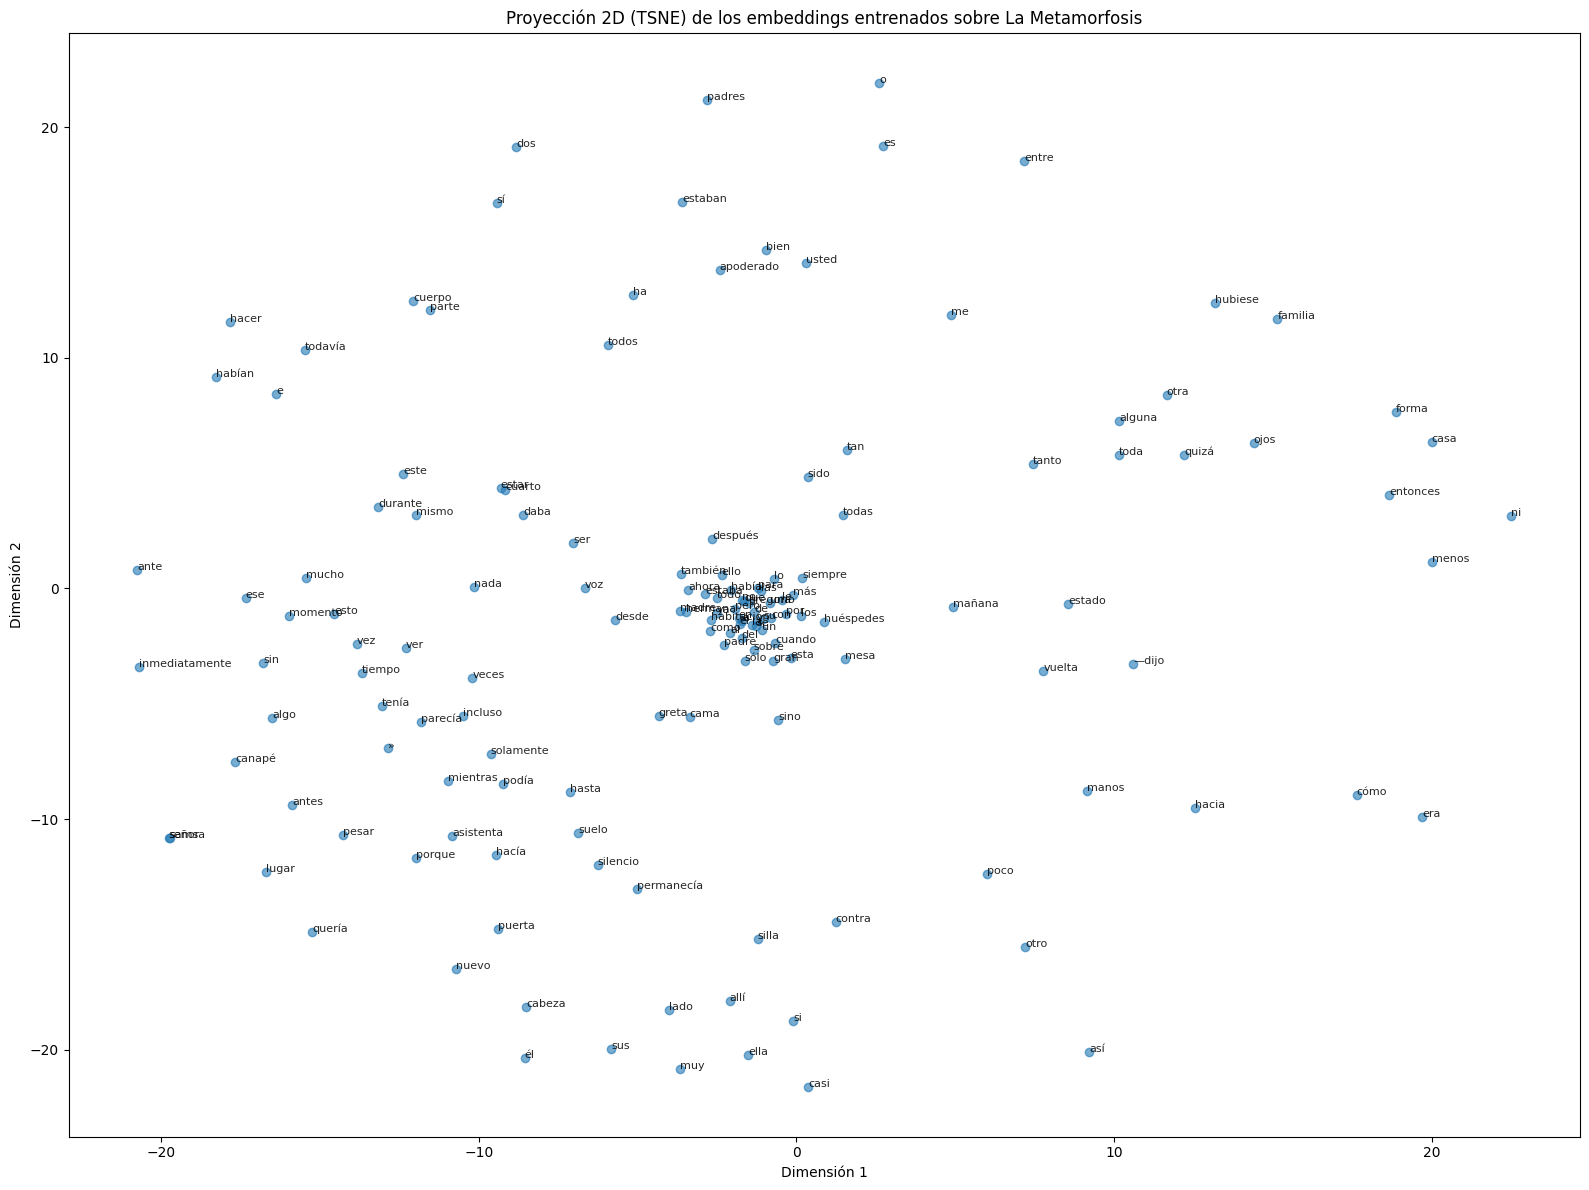

In [60]:
MAX_WORDS = 150  # cantidad de palabras a graficar, ajustada empíricamente para que el gráfico sea legible

vecs_metamorfosis, labels_metamorfosis = reduce_dimensions(w2v_model_metamorfosis, num_dimensions=2)

plt.figure(figsize=(16, 12))
plt.scatter(vecs_metamorfosis[:MAX_WORDS, 0], vecs_metamorfosis[:MAX_WORDS, 1], alpha=0.6)
for i in range(MAX_WORDS):
    plt.annotate(labels_metamorfosis[i],
                 (vecs_metamorfosis[i, 0], vecs_metamorfosis[i, 1]),
                 fontsize=8, alpha=0.85)
plt.title("Proyección 2D (TSNE) de los embeddings entrenados sobre La Metamorfosis")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.tight_layout()
plt.savefig("embeddings_metamorfosis_2d.png", dpi=150)
plt.show()

### 6 - Inspección de agrupamientos

Se inspeccionó el gráfico de la sección anterior buscando pequeños grupos de palabras cercanas entre sí, y se identificaron tres agrupamientos interpretables.

**Grupo 1 — núcleo central: personajes y espacio doméstico mezclados con palabras funcionales**

![grupo1](attachment:grupo1_nucleo.png)

En el centro del gráfico se concentra la gran mayoría de los puntos, formando una nube densa donde aparecen mezclados los nombres de los personajes (`gregorio`, `greta`, `madre`, `padre`), el espacio de la casa (`habitación`, `cama`) y una enorme cantidad de palabras funcionales (`que`, `de`, `en`, `la`, `los`, `para`, `por`, `cuando`, `sobre`, `del`, `como`, `también`, `ahora`, `estaba`, `todo`, `había`). Se interpreta que este agrupamiento no refleja tanto una cercanía semántica genuina como el efecto de trabajar con un corpus chico: los personajes y los lugares de la casa se mencionan en casi todas las oraciones de la novela, por lo que terminan rodeados de las mismas palabras funcionales que aparecen en cualquier otro lugar del texto, y sus vectores quedan atraídos hacia esa misma zona central en lugar de diferenciarse entre sí.

**Grupo 2 — adverbios y cuantificadores temporales**

![grupo2](attachment:grupo2_temporal.png)

A la izquierda del gráfico aparece un grupo bastante más consistente semánticamente, formado por adverbios de tiempo/cantidad y palabras de uso similar: `todavía`, `habían`, `este`, `durante`, `mismo`, `mucho`, `nada`, `momento`, `esto`, `vez`, `ver`, `tiempo`, `veces`, `tenía`, `parecía`, `incluso`, `solamente`, `mientras`, `podía`, `inmediatamente`, `algo`. Se interpreta que el modelo sí logró capturar aquí una categoría gramatical/discursiva compartida (marcadores temporales y de grado), separándola razonablemente bien del resto del vocabulario. Llama la atención que `canapé` (el sofá de la habitación de Grete, un objeto puntual de la novela) haya quedado dentro de este grupo: al ser una palabra de muy baja frecuencia, probablemente solo compartió contexto inmediato con algunas de estas palabras funcionales, y no con otras palabras de objetos o mobiliario.

**Grupo 3 — "familia" aislada de los personajes concretos**

![grupo3](attachment:grupo3_familia.png)

Por último, se destaca un caso puntual: la palabra `familia` aparece muy alejada del núcleo central donde están `madre`, `padre`, `hermana` y `gregorio`, formando un pequeño par junto con `hubiese`. Se interpreta que, si bien `familia` es un concepto estrechamente relacionado con esos personajes, al ser una palabra abstracta y poco frecuente en el texto (33 apariciones, y en contextos distintos a los de cada personaje mencionado individualmente) el modelo no dispuso de suficientes ejemplos como para acercarla a los nombres concretos de los integrantes de esa familia.

### Conclusiones

Se concluye que fue posible entrenar embeddings propios con Gensim a partir de un corpus muy distinto al utilizado en el ejemplo de la cátedra (una única novela corta en español, en lugar de miles de versos de canciones en inglés), aunque con resultados sensiblemente más limitados en cuanto a la calidad de las relaciones semánticas capturadas.

En cuanto a los términos de interés ensayados en la sección 4, se observó una diferencia clara según la frecuencia y la consistencia de uso de cada palabra: el término más frecuente (`gregorio`, 268 apariciones) terminó con un vector poco discriminante, dominado por palabras funcionales, mientras que términos de frecuencia intermedia y usos más consistentes (`puerta`, `hermana`) lograron capturar relaciones bastante más razonables (`puerta` con verbos de abrir/cerrar/entrar; `hermana` con `madre` como su vecino más cercano). Esto sugiere que, en corpus chicos, la cantidad de apariciones de una palabra no garantiza por sí sola una buena representación: importa también qué tan variados o consistentes son los contextos en los que aparece.

Respecto de la comparación con el ejemplo de la cátedra, se destaca un dato llamativo: el corpus de canciones, con 1846 documentos, generó un vocabulario de apenas 445 palabras (con `min_count=5`), mientras que este corpus, de un solo libro y con muchas menos oraciones (726), generó un vocabulario de 948 palabras (con `min_count=3`). Esto muestra que el tamaño del corpus en cantidad de documentos no es lo mismo que su riqueza léxica: las canciones repiten muchas veces un vocabulario simple, mientras que la prosa de Kafka (en esta traducción) es léxicamente más variada aunque el volumen total de datos de entrenamiento sea menor. Esa combinación —vocabulario relativamente grande para la cantidad de oraciones disponibles— es probablemente la causa principal de que los embeddings resultantes hayan quedado menos "afinados" que los del ejemplo de la cátedra: cada palabra tuvo, en promedio, muchos menos ejemplos de contexto para aprender de ellos.

Para compensar en parte esta limitación se redujo `vector_size` a 100, se achicó `min_count` a 3, se amplió la ventana de contexto a 5 y se entrenó durante 100 épocas en lugar de 20. Se observa en la curva de loss que el modelo mejora fuertemente en las primeras ~30 épocas (de ~268.000 a ~115.000-120.000) y luego entra en una meseta ruidosa, oscilando entre 96.000 y 100.000 durante buena parte del resto del entrenamiento, sin una mejora sostenida adicional. Esto indica que, para este corpus y esta configuración, entrenar más allá de las 40-50 épocas aporta poco, y que la meseta alcanzada es probablemente el límite que impone la cantidad de datos disponibles más que un problema de cantidad de épocas.

Finalmente, en la proyección 2D e inspección de agrupamientos (sección 5 y 6) se observó que el agrupamiento más grande y visible del gráfico (núcleo central) mezcla personajes, espacios de la casa y palabras funcionales, reflejando que estas palabras "de contenido" son también, en este corpus, de las más frecuentes, y por eso terminan compartiendo vecindario con los conectores y preposiciones más comunes del texto. En cambio, se encontró un agrupamiento de adverbios y cuantificadores temporales bastante más nítido, así como un caso interesante de una palabra abstracta (`familia`) que quedó completamente aislada de los personajes concretos que la componen. En conjunto, estos hallazgos son consistentes con la conclusión general del desafío: entrenar embeddings desde cero sobre un corpus de un único libro relativamente chico permite observar patrones interesantes y parcialmente coherentes con el contenido de la obra, pero produce representaciones sensiblemente más ruidosas que las que se obtienen con corpus más grandes, como el de canciones utilizado en el ejemplo de la cátedra.